In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d


class RocketFeatureExtractor:
    def __init__(
        self,
        hand="Right",
        orig_fps=30.0,
        target_fps=None,          # None → no downsampling
        window_sec=3.0,
        step_sec=1.0,
    ):
        self.hand = hand
        self.orig_fps = float(orig_fps)
        self.target_fps = float(target_fps) if target_fps is not None else None

        self.downsample = target_fps is not None
        self.effective_fps = self.target_fps if self.downsample else self.orig_fps

        self.dt_orig = 1.0 / self.orig_fps
        self.dt_effective = 1.0 / self.effective_fps

        self.window_size = int(window_sec * self.effective_fps)
        self.step_size = int(step_sec * self.effective_fps)

    def _calculate_4_channels(self, dfh):
        """
        Returns:
            List[np.ndarray]: each element is (T_i, 3)
                              channels = [v_mag, d_angle, palm_area]
        """
        channels_per_segment = []

        def get_pts(df, lm_prefix):
            cols = [f"{lm_prefix}_{ax}_smooth" for ax in ["x", "y"]]
            return df[cols].values

        for segment_id, df_seg in dfh.groupby("segment_id"):

            if len(df_seg) < self.window_size:
                continue

            df_seg = df_seg.sort_values("frame")

            pts0 = get_pts(df_seg, "lm_0")
            pts5 = get_pts(df_seg, "lm_5")
            pts17 = get_pts(df_seg, "lm_17")

            if (
                np.any(np.isnan(pts0))
                or np.any(np.isnan(pts5))
                or np.any(np.isnan(pts17))
            ):
                continue

            # --- Kinematics at original FPS ---
            d_pos = np.diff(pts0, axis=0, prepend=pts0[:1])
            v_mag = np.linalg.norm(d_pos, axis=1) / self.dt_orig

            v_orient = pts5 - pts0
            angles = np.arctan2(v_orient[:, 1], v_orient[:, 0])
            d_angle = np.diff(angles, prepend=angles[0])
            d_angle = (d_angle + np.pi) % (2 * np.pi) - np.pi

            v1 = pts5 - pts0
            v2 = pts17 - pts0
            palm_area = 0.5 * np.abs(
                v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0]
            )

            channels_orig = np.stack([v_mag, d_angle, palm_area], axis=1)

            # Apply a quick pass to catch derivative artifacts
            from scipy.signal import medfilt
            for c in range(channels_orig.shape[1]):
                channels_orig[:, c] = medfilt(channels_orig[:, c], kernel_size=3)

            # --- Optional downsampling ---
            if not self.downsample:
                channels_per_segment.append(channels_orig)
                continue

            n_steps = int(
                len(channels_orig) * (self.target_fps / self.orig_fps)
            )
            if n_steps < self.window_size:
                continue

            t_orig = np.arange(len(channels_orig)) * self.dt_orig
            t_target = np.arange(n_steps) * self.dt_effective

            f_chan = interp1d(
                t_orig,
                channels_orig,
                axis=0,
                kind="linear",
                fill_value="extrapolate",
            )

            channels_target = f_chan(t_target)
            channels_per_segment.append(channels_target)

        return channels_per_segment

    def prepare_rocket_windows(self, df_dict):
        all_windows = []
        video_mapping = []

        for key, df in tqdm(df_dict.items(), desc="Slicing ROCKET Windows"):
            dfh = df[df["hand_label"] == self.hand].copy()
            if len(dfh) < self.window_size:
                continue

            segment_signals = self._calculate_4_channels(dfh)

            for seg_signal in segment_signals:
                T = len(seg_signal)
                if T < self.window_size:
                    continue

                for start in range(
                    1, T - self.window_size + 1, self.step_size
                ):
                    end = start + self.window_size
                    window = seg_signal[start:end]

                    # ROCKET expects (Channels, Time)
                    all_windows.append(window.T)
                    video_mapping.append(key)

        return np.array(all_windows), video_mapping


In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

In [3]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:03<00:00, 24.37it/s]


In [21]:
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import RobustScaler

# 1. Initialize and Prepare Data
extractor = RocketFeatureExtractor(hand="Right", window_sec=3.0, step_sec=1.0)
X_windows, video_mapping = extractor.prepare_rocket_windows(df_dict)

N_tr, C, T = X_windows.shape

X_windows_flat = X_windows.transpose(0, 2, 1).reshape(-1, C)
    
    # Fit and Transform
scaler = RobustScaler()
X_windows_flat = scaler.fit_transform(X_windows_flat)
X_windows_flat = np.clip(X_windows_flat, -15, 15)

X_windows = X_windows_flat.reshape(N_tr, T, C).transpose(0, 2, 1)

# 2. Generate ROCKET Features (The "Brute Force" part)
# This will turn your 5 channels into ~10,000 features
rocket = MiniRocketMultivariate(random_state=29)
X_win_feats = rocket.fit_transform(X_windows)

# 3. Predict Residuals
# Let's say 'df_results' contains your MAE 5.0 predictions
# residuals = actual_scores - predicted_scores

# Merge ROCKET features with your residual labels using 'keys'
# and run a Ridge Regression. 
# If the R2 score is > 0.1, you have found a local signal!

Slicing ROCKET Windows:   0%|          | 0/83 [00:00<?, ?it/s]

Slicing ROCKET Windows: 100%|██████████| 83/83 [28:17<00:00, 20.45s/it]    


In [5]:
X_win_feats.shape

(30598, 9996)

In [6]:
"""
df_rocket = pd.DataFrame(X_win_feats)
df_rocket['video_key'] = video_mapping
video_level_rocket = df_rocket.groupby('video_key').max()"""



# 1. Convert to DataFrame
df_win = pd.DataFrame(X_win_feats)
df_win['video_key'] = video_mapping

# 2. Multi-aggregate
# This captures consistency (mean), peak clumsiness (max), and erraticness (std)
video_level_rocket = df_win.groupby('video_key').agg(['mean', 'max', 'std'])
video_level_rocket.columns = [f"{c[0]}_{c[1]}" for c in video_level_rocket.columns]


"""
# smth to try:
# also remember next thing to do is double check expert rating MAE and std!!!

df_win = pd.DataFrame(X_win_feats)
df_win['video_key'] = video_mapping

video_level_rocket = (
    df_win
    .groupby('video_key')
    .agg([
        'mean',
        'std',
        lambda x: np.percentile(x, 99),
        #lambda x: np.percentile(x, 10)
    ])
)


video_level_rocket.columns = [
    f"{col}_{stat}" for col, stat in video_level_rocket.columns
]
"""


'\n# smth to try:\n# also remember next thing to do is double check expert rating MAE and std!!!\n\ndf_win = pd.DataFrame(X_win_feats)\ndf_win[\'video_key\'] = video_mapping\n\nvideo_level_rocket = (\n    df_win\n    .groupby(\'video_key\')\n    .agg([\n        \'mean\',\n        \'std\',\n        lambda x: np.percentile(x, 99),\n        #lambda x: np.percentile(x, 10)\n    ])\n)\n\n\nvideo_level_rocket.columns = [\n    f"{col}_{stat}" for col, stat in video_level_rocket.columns\n]\n'

In [8]:
video_level_rocket.columns

Index(['0_mean', '0_max', '0_std', '1_mean', '1_max', '1_std', '2_mean',
       '2_max', '2_std', '3_mean',
       ...
       '9992_std', '9993_mean', '9993_max', '9993_std', '9994_mean',
       '9994_max', '9994_std', '9995_mean', '9995_max', '9995_std'],
      dtype='object', length=29988)

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

n = 50
# --- 1. Distill ROCKET Features ---
# We use PCA because 10,000 features on 83 samples is "Overfitting Suicide"
pca_rocket = PCA(n_components=n) # Keep top 15 temporal patterns
rocket_pca_features = pca_rocket.fit_transform(video_level_rocket)

# Convert to DataFrame for merging
df_rocket_pca = pd.DataFrame(
    rocket_pca_features, 
    index=video_level_rocket.index, 
    columns=[f'Rocket_PC{i+1}' for i in range(n)]
)

In [10]:
df_rocket_pca = df_rocket_pca.reset_index()

In [11]:
# load 
df_metrics = pd.read_csv("data/metrics/best_global_metrics2.csv")
df_metrics.head()



,Participant Number,GRS_Total,QRS_Overal,Case_Number,adjusted_total_path_Right,total_duration_Right,num_reversals_Right,velocity_corr,interhand_dist_change_rms,mean_abs_angle_change_Right
0,1,59.25,48.50,1,62034.389107,534.933333,737,0.300569,37.862266,0.726575
1,1,54.40,45.00,2,37353.044239,288.033333,378,0.642479,37.941429,0.899482
2,1,74.50,60.50,3,51364.691660,423.033333,694,0.476772,39.133227,0.929110
3,2,49.25,39.25,1,103592.752300,1281.533333,1571,0.356040,23.805603,0.726725
4,2,49.00,38.00,2,74343.087367,1010.833333,1133,0.475344,21.928832,0.714639


In [12]:
df_combined = pd.merge(df_rocket_pca, df_metrics, left_index=True, right_index=True)

In [13]:

global_features = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
rocket_features = [f'Rocket_PC{i+1}' for i in range(n)]

# for each of the features correlation with QRS_Overal
for feature in global_features + rocket_features:
    corr = df_combined[feature].corr(df_combined['QRS_Overal'])
    print(f"Correlation between {feature} and QRS_Overal: {corr:.4f}")

Correlation between adjusted_total_path_Right and QRS_Overal: -0.7176
Correlation between total_duration_Right and QRS_Overal: -0.6843
Correlation between num_reversals_Right and QRS_Overal: -0.7203
Correlation between velocity_corr and QRS_Overal: -0.0071
Correlation between Rocket_PC1 and QRS_Overal: -0.0771
Correlation between Rocket_PC2 and QRS_Overal: -0.0248
Correlation between Rocket_PC3 and QRS_Overal: -0.3895
Correlation between Rocket_PC4 and QRS_Overal: -0.4690
Correlation between Rocket_PC5 and QRS_Overal: -0.2740
Correlation between Rocket_PC6 and QRS_Overal: -0.1633
Correlation between Rocket_PC7 and QRS_Overal: -0.0907
Correlation between Rocket_PC8 and QRS_Overal: 0.0099
Correlation between Rocket_PC9 and QRS_Overal: -0.0709
Correlation between Rocket_PC10 and QRS_Overal: 0.0761
Correlation between Rocket_PC11 and QRS_Overal: -0.1983
Correlation between Rocket_PC12 and QRS_Overal: 0.0871
Correlation between Rocket_PC13 and QRS_Overal: 0.0310
Correlation between Rocket_P

In [47]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from matplotlib import pyplot as plt


def candidate_vs_pca_explainability(
    df,
    candidate_features,
    target='QRS_Overal',
    pcs_to_use=[0],
    pca_features=[
        'adjusted_total_path_Right',
        'total_duration_Right',
        'num_reversals_Right',
        'velocity_corr'
    ]
):
    """
    Quantifies how much additional variance candidate features explain
    beyond PCA-derived components.

    pcs_to_use: list of PC indices (e.g., [0] or [0,1,2])
    """

    df_clean = df.dropna(
        subset=[target] + candidate_features + pca_features
    ).copy()

    # ==============================
    # 1. PCA (fixed feature set)
    # ==============================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[pca_features])

    pca = PCA(n_components=3)
    PCs = pca.fit_transform(X_scaled)

    pc_cols = [f'PC{i+1}' for i in range(3)]
    for i, col in enumerate(pc_cols):
        df_clean[col] = PCs[:, i]

    used_pc_cols = [pc_cols[i] for i in pcs_to_use]

    # ==============================
    # 2. Baseline model (PCs only)
    # ==============================
    y = df_clean[target].values

    pc_model = LinearRegression()
    pc_model.fit(df_clean[used_pc_cols], y)

    pc_preds = pc_model.predict(df_clean[used_pc_cols])
    pc_residuals = y - pc_preds
    pc_resid_var = np.var(pc_residuals)

    # ==============================
    # 3. Candidate feature contribution
    # ==============================
    results = []

    for feat in candidate_features:
        X_full = df_clean[used_pc_cols + [feat]]

        full_model = LinearRegression()
        full_model.fit(X_full, y)

        full_preds = full_model.predict(X_full)
        full_resid = y - full_preds
        full_resid_var = np.var(full_resid)

        partial_r2 = 1 - (full_resid_var / pc_resid_var)

        r, p = pearsonr(df_clean[feat], pc_residuals)

        results.append({
            'Feature': feat,
            'Partial_R2_vs_PCs': partial_r2,
            'Corr_with_PC_residuals': r,
            'p-value': p
        })

    res_df = (
        pd.DataFrame(results)
        .sort_values('Partial_R2_vs_PCs', ascending=False)
    )

    return res_df, pca.explained_variance_ratio_

df_res, _ = candidate_vs_pca_explainability(df_combined, rocket_features, pcs_to_use=[0,1,2])
df_res


,Feature,Partial_R2_vs_PCs,Corr_with_PC_residuals,p-value
1,Rocket_PC2,0.092465,-0.253911,0.020544
13,Rocket_PC14,0.076521,0.270823,0.013273
8,Rocket_PC9,0.065780,-0.253949,0.020525
12,Rocket_PC13,0.042121,0.200900,0.068585
9,Rocket_PC10,0.037622,-0.191206,0.083352
31,Rocket_PC32,0.034449,0.183064,0.097615
36,Rocket_PC37,0.034441,-0.184844,0.094344
15,Rocket_PC16,0.024569,0.154040,0.164406
44,Rocket_PC45,0.017980,0.132701,0.231726
2,Rocket_PC3,0.014889,-0.102033,0.358690


In [14]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.linear_model import Ridge, RidgeCV

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0, 1, 2],
    pca_features=['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = Ridge(alpha=0.5)
        pc_model.fit(df_train[used_pc_cols], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols])
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols + [feat]]
            full_model = Ridge(alpha=0.5)
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Partial_R2'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= 3]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('Mean_Partial_R2', ascending=False)

# Usage:
df_res_leakage_free = leakage_free_residual_analysis(df_combined, rocket_features)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:07<00:00,  3.88it/s]


,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,Selection_Stability
18,Rocket_PC26,0.058820,0.014313,-0.237138,0.031800,0.857143
5,Rocket_PC14,0.058241,0.008581,0.237999,0.018164,0.821429
26,Rocket_PC33,0.057938,0.010667,-0.238371,0.021900,0.750000
22,Rocket_PC3,0.043548,0.013000,-0.189288,0.027345,0.178571
43,Rocket_PC49,0.041257,0.009469,0.201522,0.023143,0.071429
6,Rocket_PC15,0.039746,0.006067,0.195884,0.015002,0.035714
48,Rocket_PC8,0.038402,0.008792,0.191792,0.020836,0.071429
15,Rocket_PC23,0.038310,0.010637,0.191882,0.032279,0.107143
45,Rocket_PC50,0.037563,0.009031,0.192539,0.025443,0.035714
2,Rocket_PC11,0.032753,0.013921,-0.175511,0.030372,0.035714


In [15]:
# analyse components of the top PC
top_rocket_pc = df_res_leakage_free.iloc[0]['Feature']
top_rocket_pc


'Rocket_PC2'

In [16]:
top_features = df_res_leakage_free[df_res_leakage_free['Selection_Stability'] >= 0.7]['Feature'].tolist()
top_features

['Rocket_PC2']

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 162.11it/s]


          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7608
Overall MAE: 5.0675
Overall Std Dev of Errors: 3.4154

--- Per-Fold Performance Summary ---
           Train_MAE  Test_MAE  Test_Corr
SurgeonID                                
1           4.590393  5.694715   0.468418
2           4.650167  3.873276   0.806017
3           4.594184  7.745751   0.833728
4           4.552730  7.269769  -0.173994
5           4.528250  7.505247   0.998754
6           4.731479  2.962238   0.743064
7           4.431069  9.315103  -0.684951
9           4.672400  5.868585  -0.856687
10          4.696062  5.353216   0.998778
11          4.751135  2.564788   0.795442
12          4.717997  3.931505  -0.996926
13          4.756553  2.009449   0.995825
14          4.627857  5.341787   0.712590
15          4.636071  7.090416   0.992045
16          4.419443  9.772321  -0.610462
17          4.790814  1.289413   0.968584
18          4.503947  8.275660   0.914180
19          4.605000  5.410604 

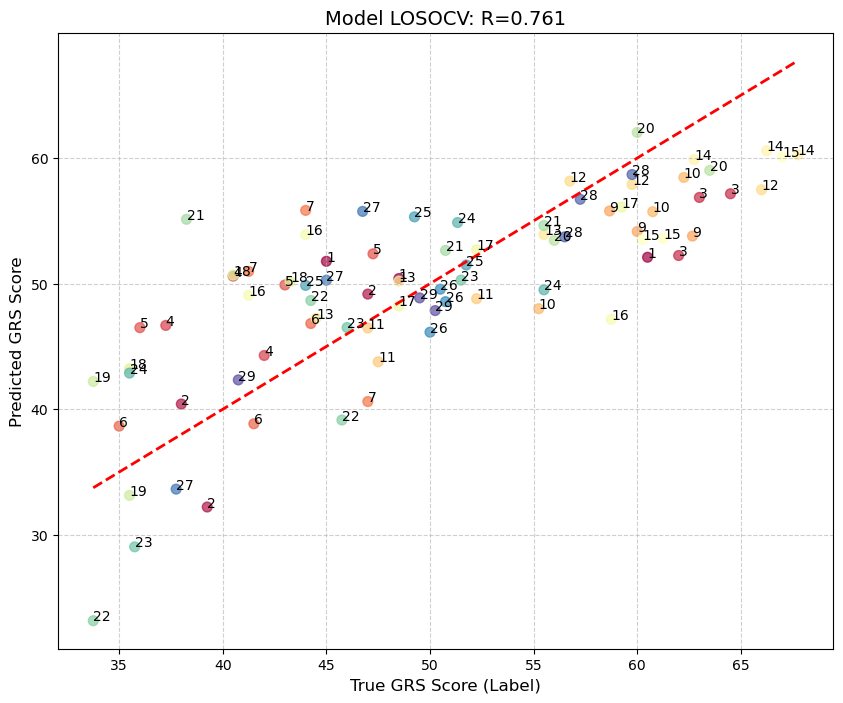

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and c§orrectly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']]#, 'velocity_corr']]
additional_feature_cols = top_features #['mean_abs_angle_change_Right']#['Rocket_PC27', 'Rocket_PC7', 'Rocket_PC19', 'Rocket_PC5', 'Rocket_PC24', 'Rocket_PC40']  # 'Rocket_PC25', 'Rocket_PC21', 'Rocket_PC22'
all_feature_cols = feature_cols + additional_feature_cols
X = df_combined[all_feature_cols].values
y = df_combined['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = df_combined['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0,1,2]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5)                    # RidgeCV(alphas=np.logspace(-2, 4, 20)). TO CHANGE LATER
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# PC selection within the LOSO loop

In [160]:
# --- 1. Setup ---
# all_rocket_cols should be your full list of candidate features (e.g., all 40+ Rocket PCs)
feature_cols = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
all_rocket_cols = [col for col in df_combined.columns if 'Rocket_PC' in col] 

X_global = df_combined[feature_cols].values
X_rocket = df_combined[all_rocket_cols].values
y = df_combined['QRS_Overal'].values
surgeon_ids = df_combined['Participant Number'].values
unique_surgeons = np.unique(surgeon_ids)

predictions = []
true_scores = []
all_fold_surgeons = []
top_rocket_features_per_fold = {1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8:[], 9: [], 10: []}  # To track top features per fold
all_top_corrs = []

print(f"Starting Leakage-Free LOSOCV (Selection inside the loop)...")

for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    # Split
    test_idx = np.where(surgeon_ids == surgeon_out)[0]
    train_idx = np.where(surgeon_ids != surgeon_out)[0]
    
    # --- A. Scaling (Train only) ---
    scaler = StandardScaler()
    X_train_glob = scaler.fit_transform(X_global[train_idx])
    X_test_glob = scaler.transform(X_global[test_idx])
    
    scaler_r = StandardScaler()
    X_train_rock = scaler_r.fit_transform(X_rocket[train_idx])
    X_test_rock = scaler_r.transform(X_rocket[test_idx])
    
    # --- B. Global PCA (Exactly as before) ---
    pca = PCA(n_components=3)
    X_train_pca = pca.fit_transform(X_train_glob)
    X_test_pca = pca.transform(X_test_glob)
    
    # --- C. Internal Feature Selection (The "Zero-Leakage" Step) ---
    # 1. Fit baseline model to get residuals on training data
    baseline_model = Ridge(alpha=0.5).fit(X_train_pca, y[train_idx])
    train_residuals = y[train_idx] - baseline_model.predict(X_train_pca)
    
    # 2. Find which Rocket features correlate best with training residuals
    # We use Pearson R here as it's the core of your previous residual analysis
    fold_corrs = []
    partial_r2s = []
    for i in range(X_train_rock.shape[1]):
        """X_full = X_full = np.column_stack([X_train_pca, X_train_rock[:, i]])
        full_model = LinearRegression().fit(X_full, y[train_idx])
        full_resid = y[train_idx] - full_model.predict(X_full)
        full_resid_var = np.var(full_resid)
        partial_r2 = 1 - (full_resid_var / np.var(train_residuals))
        partial_r2s.append(partial_r2)"""

        r, _ = pearsonr(X_train_rock[:, i], train_residuals)
        fold_corrs.append(abs(r))
    
    # select features with partial R2 > 0.05 and abs(corr) > 0.2
    """fold_corrs = np.array(fold_corrs)
    partial_r2s = np.array(partial_r2s)
    top_subset_idx = np.where((partial_r2s > 0.05) & (fold_corrs > 0.2))[0]"""

    #for i, idx in enumerate(top_subset_idx):
        #d=1
        #top_rocket_features_per_fold[i+1].append(idx)"""


    # 3. Pick Top 6 features for THIS fold specifically
    top_subset_idx = np.argsort(fold_corrs)[-1:].tolist()
    top_subset_idx.reverse()  # Top 6 indices

    top_corrs = np.array(fold_corrs)[top_subset_idx]
    for c in top_corrs:
        all_top_corrs.append(c)
        if c < 0.15:
            top_subset_idx.remove(top_subset_idx[np.where(top_corrs == c)[0][0]])
            top_corrs = top_corrs[top_corrs != c]


    # DEBUG
    #top_subset_idx = [26, 53, 6]

    for i, idx in enumerate(top_subset_idx):  # reversed to have highest first
        d=1
        #top_rocket_features_per_fold[i+1].append(idx)
    
    # --- D. Combine and Predict ---
    X_train_final = np.hstack((X_train_pca, X_train_rock[:, top_subset_idx]))
    X_test_final = np.hstack((X_test_pca, X_test_rock[:, top_subset_idx]))
    
    # Use your fixed alpha=0.5 Ridge model
    model = Ridge(alpha=0.5)#RidgeCV(alphas=np.logspace(-1, 3, 20))
    model.fit(X_train_final, y[train_idx])
    
    y_test_pred = model.predict(X_test_final)
    
    predictions.extend(y_test_pred)
    true_scores.extend(y[test_idx])
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 2. Evaluation ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

print(f"\nFINAL VALID RESULTS:")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"Overall Correlation: {hybrid_corr:.4f}")

Starting Leakage-Free LOSOCV (Selection inside the loop)...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 30.15it/s]


FINAL VALID RESULTS:
Overall MAE: 5.1983
Overall Std Dev of Errors: 4.0795
Overall Correlation: 0.7035


# Try with Raw Rocket Kernel features

In [15]:
def fast_correlation(X, y_residuals):
    """
    X: shape (num_surgeons, 30000)
    y_residuals: shape (num_surgeons,)
    """
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    y_centered = y_residuals - np.mean(y_residuals)
    
    # Vectorized Pearson R formula
    numerator = np.dot(X_centered.T, y_centered)
    denominator = np.sqrt(np.sum(X_centered**2, axis=0) * np.sum(y_centered**2))
    
    # Avoid division by zero
    return np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import numpy as np


# --- 1. Setup ---
# all_rocket_cols should be your full list of candidate features (e.g., all 40+ Rocket PCs)
feature_cols = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']

X_global = df_metrics[feature_cols].values
X_rocket_raw = video_level_rocket.values
y = df_metrics['QRS_Overal'].values
#y = np.random.permutation(y)
surgeon_ids = df_metrics['Participant Number'].values
unique_surgeons = np.unique(surgeon_ids)

predictions = []
true_scores = []
all_fold_surgeons = [] 

top_rocket_features = dict() 

print(f"Starting Raw Kernel Selection LOSOCV...")

for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    train_idx = np.where(surgeon_ids != surgeon_out)[0]
    test_idx = np.where(surgeon_ids == surgeon_out)[0]
    
    # Standardize Global and RAW Rocket
    scaler_g = StandardScaler().fit(X_global[train_idx])
    scaler_r = StandardScaler().fit(X_rocket_raw[train_idx])
    
    X_train_pca = PCA(n_components=3).fit_transform(scaler_g.transform(X_global[train_idx]))
    X_test_pca = PCA(n_components=3).fit(scaler_g.transform(X_global[train_idx])).transform(scaler_g.transform(X_global[test_idx]))
    
    X_train_raw = scaler_r.transform(X_rocket_raw[train_idx])
    X_test_raw = scaler_r.transform(X_rocket_raw[test_idx])
    
    # --- INTERNAL SELECTION ON RAW KERNELS ---
    # Calculate residuals from global model
    base_model = Ridge(alpha=0.5).fit(X_train_pca, y[train_idx])
    train_resid = y[train_idx] - base_model.predict(X_train_pca)
    #train_resid = np.random.permutation(train_resid)  # For Null Test Shuffle
    
    # 1. Find Top 5 Raw Kernels out of 10,000
    # (Pearson correlation is fast enough for 10k)
    
    
    corrs = np.array([(fast_correlation(X_train_raw[:, i], train_resid)) for i in range(video_level_rocket.shape[1])])
    #top_raw_indices = np.argsort(corrs)[-10:] # Let's try Top 5
    top_raw_indices = np.where((corrs > 0.35) | (corrs < -0.35))[0].tolist()

    for idx in top_raw_indices:
        corr = corrs[idx]
        if idx not in top_rocket_features:
            top_rocket_features[idx] = {'count': 0, 'corrs': []}
            top_rocket_features[idx]['count'] = 1
            top_rocket_features[idx]['corrs'].append(corr)
        else:
            top_rocket_features[idx]['count'] += 1
            top_rocket_features[idx]['corrs'].append(corr)

    #print(f"Selected Raw Kernel Indices for Surgeon {surgeon_out}: {top_raw_indices}, Correlations: {corrs[top_raw_indices]}")
    
    top_raw_indices = [24166]
    
    # 2. Combine Global PCA + 5 Raw "Expert" Kernels
    X_train_final = np.hstack([X_train_pca, X_train_raw[:, top_raw_indices]])
    X_test_final = np.hstack([X_test_pca, X_test_raw[:, top_raw_indices]])
    
    # 3. Train with heavy regularization (RidgeCV is best here)
    model = RidgeCV(alphas=np.logspace(0, 5, 20)) 
    model.fit(X_train_final, y[train_idx])
    
    predictions.extend(model.predict(X_test_final))
    true_scores.extend(y[test_idx])

# --- 2. Evaluation ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

print(f"\nFINAL VALID RESULTS:")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"Overall Correlation: {hybrid_corr:.4f}")

Starting Raw Kernel Selection LOSOCV...


LOSOCV Folds: 100%|██████████| 28/28 [00:43<00:00,  1.57s/it]


FINAL VALID RESULTS:
Overall MAE: 5.1102
Overall Std Dev of Errors: 3.7900
Overall Correlation: 0.7524


In [17]:
top_rocket_features

{21457: {'count': 26,
  'corrs': [np.float64(-0.3676325970014598),
   np.float64(-0.3787096631977037),
   np.float64(-0.42735864683958125),
   np.float64(-0.35733928888721067),
   np.float64(-0.4066266304171892),
   np.float64(-0.371645061600018),
   np.float64(-0.366858534790411),
   np.float64(-0.3800084929930474),
   np.float64(-0.3667486840513169),
   np.float64(-0.3546483795369526),
   np.float64(-0.3652160275536425),
   np.float64(-0.3722873157121441),
   np.float64(-0.3927636363042379),
   np.float64(-0.35726277134129736),
   np.float64(-0.3680389003511765),
   np.float64(-0.3945671976923173),
   np.float64(-0.3597795661953196),
   np.float64(-0.36837930864088786),
   np.float64(-0.36275092432177397),
   np.float64(-0.3939663385274417),
   np.float64(-0.36901542127329107),
   np.float64(-0.3712966798005155),
   np.float64(-0.36690279069872067),
   np.float64(-0.3732336849290953),
   np.float64(-0.3799174719107315),
   np.float64(-0.3690003589067463)]},
 21472: {'count': 22,
  'c

In [18]:
# number of kernels that where selected in ALL fols
consistent_kernels = [k for k, v in top_rocket_features.items() if v['count'] == len(unique_surgeons)]
consistent_kernels

[]

# Is the result just random luck?

In [55]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# --- Configuration ---
n_seeds = 10  # Set the number of shuffles you want to test
threshold = 0.35
feature_cols = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']

X_global = df_metrics[feature_cols].values
X_rocket_raw = video_level_rocket.values
y = df_metrics['QRS_Overal'].values
unique_surgeons = np.unique(surgeon_ids)

all_seed_data = []

print(f"Starting Multi-Seed Consistent Residual-Shuffle Test...")

for seed in range(n_seeds):
    print(f"\n--- RUNNING SEED {seed} ---")
    
    # 0. PRE-COMPUTE CONSISTENT SHUFFLE MAP FOR THIS SEED
    np.random.seed(seed)
    num_samples = len(y)
    shuffled_indices = np.random.permutation(np.arange(num_samples))
    
    top_rocket_features = dict() 

    # 1. Run LOSOCV
    for surgeon_out in tqdm(unique_surgeons, desc=f"Seed {seed} Folds", leave=False):
        train_idx = np.where(surgeon_ids != surgeon_out)[0]
        
        # A. Standardize and PCA on REAL training data
        scaler_g = StandardScaler().fit(X_global[train_idx])
        scaler_r = StandardScaler().fit(X_rocket_raw[train_idx])
        
        # Fit PCA on training set only
        pca_model = PCA(n_components=3).fit(scaler_g.transform(X_global[train_idx]))
        X_train_pca = pca_model.transform(scaler_g.transform(X_global[train_idx]))
        X_train_raw = scaler_r.transform(X_rocket_raw[train_idx])
        
        # B. Get REAL residuals for the training set
        base_model = Ridge(alpha=0.5).fit(X_train_pca, y[train_idx])
        
        # C. Apply consistent shuffle based on the Global Pool
        # Note: We scale/transform the FULL global set using this fold's parameters
        full_pca_fold = pca_model.transform(scaler_g.transform(X_global))
        full_residuals_fold = y - base_model.predict(full_pca_fold)
        
        # Scramble using the seed-specific master map
        shuffled_pool = full_residuals_fold[shuffled_indices]
        train_resid_shuffled = shuffled_pool[train_idx]
        
        # D. Correlation check
        corrs = np.array([abs(fast_correlation(X_train_raw[:, i], train_resid_shuffled)) 
                          for i in range(X_train_raw.shape[1])])
        
        top_raw_indices = np.where(corrs > threshold)[0].tolist()

        for idx in top_raw_indices:
            top_rocket_features[idx] = top_rocket_features.get(idx, 0) + 1

    # 2. Identify consistent kernels for this seed
    consistent_kernels = [k for k, v in top_rocket_features.items() if v == len(unique_surgeons)]
    
    all_seed_data.append({
        "seed": seed,
        "count": len(consistent_kernels),
        "indices": consistent_kernels
    })
    
    print(f"RESULT SEED {seed}: Found {len(consistent_kernels)} consistent kernels. Indices: {consistent_kernels}")

# --- Final Summary ---
print("\n" + "="*50)
print("FINAL NULL DISTRIBUTION SUMMARY")
print("="*50)
summary_df = pd.DataFrame(all_seed_data)
print(summary_df)

p_value = len(summary_df[summary_df['count'] > 0]) / n_seeds
print(f"\nEmpirical p-value (prob. of finding ANY consistent kernel): {p_value:.4f}")

Starting Multi-Seed Consistent Residual-Shuffle Test...

--- RUNNING SEED 0 ---


RESULT SEED 0: Found 0 consistent kernels. Indices: []

--- RUNNING SEED 1 ---


RESULT SEED 1: Found 1 consistent kernels. Indices: [14797]

--- RUNNING SEED 2 ---


RESULT SEED 2: Found 82 consistent kernels. Indices: [614, 618, 628, 629, 642, 644, 653, 666, 668, 681, 692, 705, 707, 1226, 1263, 1265, 1302, 2558, 2597, 2621, 2636, 3315, 3480, 3543, 3642, 4413, 4476, 4707, 4770, 5112, 5175, 6855, 6918, 6941, 6956, 6963, 6965, 6980, 6987, 7002, 7004, 7019, 7026, 7028, 7047, 7049, 7110, 7558, 7584, 7621, 8217, 9996, 10163, 10292, 10740, 10797, 10821, 11052, 11115, 11231, 11469, 11493, 11508, 11532, 11543, 11565, 11582, 11685, 11709, 11724, 12453, 12477, 12588, 15975, 18954, 20341, 20356, 20365, 25710, 27114, 29232, 29304]

--- RUNNING SEED 3 ---


RESULT SEED 3: Found 0 consistent kernels. Indices: []

--- RUNNING SEED 4 ---


KeyboardInterrupt: 

In [151]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# --- Configuration ---
n_seeds = 25  # Set the number of shuffles you want to test
threshold = 0.35
feature_cols = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']

X_global = df_metrics[feature_cols].values
X_rocket_raw = video_level_rocket.values
y = df_metrics['QRS_Overal'].values
unique_surgeons = np.unique(surgeon_ids)

all_seed_data = []

print(f"Starting Multi-Seed Consistent Residual-Shuffle Test...")

for seed in range(1):
    print(f"\n--- RUNNING SEED 24 ---")
    
    # 0. PRE-COMPUTE CONSISTENT SHUFFLE MAP FOR THIS SEED
    seed = 2
    np.random.seed(seed)
    num_samples = len(y)
    shuffled_indices = np.random.permutation(np.arange(num_samples))
    
    top_rocket_features = dict() 

    # 1. Run LOSOCV
    for surgeon_out in tqdm(unique_surgeons, desc=f"Seed {seed} Folds", leave=False):
        train_idx = np.where(surgeon_ids != surgeon_out)[0]
        
        # A. Standardize and PCA on REAL training data
        scaler_g = StandardScaler().fit(X_global[train_idx])
        scaler_r = StandardScaler().fit(X_rocket_raw[train_idx])
        
        # Fit PCA on training set only
        pca_model = PCA(n_components=3).fit(scaler_g.transform(X_global[train_idx]))
        X_train_pca = pca_model.transform(scaler_g.transform(X_global[train_idx]))
        X_train_raw = scaler_r.transform(X_rocket_raw[train_idx])
        
        # B. Get REAL residuals for the training set
        base_model = Ridge(alpha=0.5).fit(X_train_pca, y[train_idx])
        
        # C. Apply consistent shuffle based on the Global Pool
        # Note: We scale/transform the FULL global set using this fold's parameters
        full_pca_fold = pca_model.transform(scaler_g.transform(X_global))
        full_residuals_fold = y - base_model.predict(full_pca_fold)
        
        # Scramble using the seed-specific master map
        shuffled_pool = full_residuals_fold[shuffled_indices]
        train_resid_shuffled = shuffled_pool[train_idx]
        
        # D. Correlation check
        corrs = np.array([(fast_correlation(X_train_raw[:, i], train_resid_shuffled)) 
                          for i in range(X_train_raw.shape[1])])
        
        top_raw_indices = np.where((corrs > threshold) | (corrs < -threshold))[0].tolist()

        for idx in top_raw_indices:
            corr = corrs[idx]
            if idx not in top_rocket_features:
                top_rocket_features[idx] = {'count': 0, 'corrs': []}
                top_rocket_features[idx]['count'] = 1
                top_rocket_features[idx]['corrs'].append(corr)
            else:
                top_rocket_features[idx]['count'] += 1
                top_rocket_features[idx]['corrs'].append(corr)

    # 2. Identify consistent kernels for this seed
    consistent_kernels = [k for k, v in top_rocket_features.items() if v['count'] == len(unique_surgeons)]
    
    all_seed_data.append({
        "seed": seed,
        "count": len(consistent_kernels),
        "indices": consistent_kernels
    })
    
    print(f"RESULT SEED {seed}: Found {len(consistent_kernels)} consistent kernels. Indices: {consistent_kernels}")

# --- Final Summary ---
print("\n" + "="*50)
print("FINAL NULL DISTRIBUTION SUMMARY")
print("="*50)
summary_df = pd.DataFrame(all_seed_data)
print(summary_df)

p_value = len(summary_df[summary_df['count'] > 0]) / n_seeds
print(f"\nEmpirical p-value (prob. of finding ANY consistent kernel): {p_value:.4f}")

Starting Multi-Seed Consistent Residual-Shuffle Test...

--- RUNNING SEED 24 ---


RESULT SEED 2: Found 17 consistent kernels. Indices: [7205, 23773, 25996, 25999, 26005, 26008, 26014, 26020, 26023, 26029, 26032, 26035, 26038, 26044, 28393, 28417, 29131]

FINAL NULL DISTRIBUTION SUMMARY
   seed  count                                            indices
0     2     17  [7205, 23773, 25996, 25999, 26005, 26008, 2601...

Empirical p-value (prob. of finding ANY consistent kernel): 0.0400


# Try to understand the top rocket features

In [152]:
# all kernels are max features
# since aggregate features are in order mean, max, std
[c % 3 for c in consistent_kernels]

[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [153]:
rocket.parameters[0].shape

(252,)

In [154]:
len(rocket.parameters)

5

In [155]:
import numpy as np
import pandas as pd

def get_kernel_weights(pattern_id):
    # This is the exact indices array from the sktime source code you provided
    indices = np.array([
        [0, 1, 2], [0, 1, 3], [0, 1, 4], [0, 1, 5], [0, 1, 6], [0, 1, 7], [0, 1, 8],
        [0, 2, 3], [0, 2, 4], [0, 2, 5], [0, 2, 6], [0, 2, 7], [0, 2, 8], [0, 3, 4],
        [0, 3, 5], [0, 3, 6], [0, 3, 7], [0, 3, 8], [0, 4, 5], [0, 4, 6], [0, 4, 7],
        [0, 4, 8], [0, 5, 6], [0, 5, 7], [0, 5, 8], [0, 6, 7], [0, 6, 8], [0, 7, 8],
        [1, 2, 3], [1, 2, 4], [1, 2, 5], [1, 2, 6], [1, 2, 7], [1, 2, 8], [1, 3, 4],
        [1, 3, 5], [1, 3, 6], [1, 3, 7], [1, 3, 8], [1, 4, 5], [1, 4, 6], [1, 4, 7],
        [1, 4, 8], [1, 5, 6], [1, 5, 7], [1, 5, 8], [1, 6, 7], [1, 6, 8], [1, 7, 8],
        [2, 3, 4], [2, 3, 5], [2, 3, 6], [2, 3, 7], [2, 3, 8], [2, 4, 5], [2, 4, 6],
        [2, 4, 7], [2, 4, 8], [2, 5, 6], [2, 5, 7], [2, 5, 8], [2, 6, 7], [2, 6, 8],
        [2, 7, 8], [3, 4, 5], [3, 4, 6], [3, 4, 7], [3, 4, 8], [3, 5, 6], [3, 5, 7],
        [3, 5, 8], [3, 6, 7], [3, 6, 8], [3, 7, 8], [4, 5, 6], [4, 5, 7], [4, 5, 8],
        [4, 6, 7], [4, 6, 8], [4, 7, 8], [5, 6, 7], [5, 6, 8], [5, 7, 8], [6, 7, 8]
    ])
    
    # Start with background weight of -1
    weights = np.full(9, -1)
    
    # Set the 3 focus positions to 2
    focus_positions = indices[pattern_id]
    weights[focus_positions] = 2
    
    return weights

def decode_consensus_kernels(consistent_indices, rocket_params):
    # Unpack the parameters as they appear in the return of _fit_multi
    (num_ch_per_comb, ch_indices, dilations, 
     num_feat_per_dilation, biases) = rocket_params
    
    num_kernels = 84
    results = []
    
    # Pre-calculate start points for channel indices
    ch_starts = np.insert(np.cumsum(num_ch_per_comb), 0, 0)

    for global_idx in consistent_indices:
        # 1. Reverse the aggregation (mean/max/std mapping)
        # Assuming your training DF order was [f0_mean, f0_max, f0_std, f1_mean...]
        raw_feature_index = global_idx // 3
        agg_type = ["mean", "max", "std"][global_idx % 3]

        # 2. Find the Dilation Group
        # Features are grouped by dilation first
        cumulative_feats = np.cumsum(num_feat_per_dilation * num_kernels)
        dilation_idx = np.searchsorted(cumulative_feats, raw_feature_index, side='right')
        
        # 3. Find Kernel and Combination Index
        dilation_start = cumulative_feats[dilation_idx - 1] if dilation_idx > 0 else 0
        idx_within_dilation = raw_feature_index - dilation_start
        
        # combination_index increments for every kernel_index in the code
        kernel_index = idx_within_dilation // num_feat_per_dilation[dilation_idx]
        kernel = get_kernel_weights(kernel_index)
        global_combination_idx = (dilation_idx * num_kernels) + kernel_index
        
        # 4. Map back to Channels
        c_start = ch_starts[global_combination_idx]
        c_end = c_start + num_ch_per_comb[global_combination_idx]
        channels = ch_indices[c_start:c_end]

        results.append({
            "Original_Col": global_idx,
            "Agg_Type": agg_type,
            "Dilation": dilations[dilation_idx],
            "Window_Size_Sec": (9 * dilations[dilation_idx]) / 10, # 10fps
            "Channels": channels.tolist(),
            "Kernel_Pattern": kernel,
            "Bias_Value": biases[raw_feature_index]
        })

    return pd.DataFrame(results)

decode_consensus_kernels(consistent_kernels, rocket.parameters)

,Original_Col,Agg_Type,Dilation,Window_Size_Sec,Channels,Kernel_Pattern,Bias_Value
0,7205,std,1,0.9,[2],"[-1, 2, -1, 2, -1, -1, -1, 2, -1]",901.173401
1,23773,max,2,1.8,[0],"[-1, -1, -1, 2, -1, 2, 2, -1, -1]",1742.589966
2,25996,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000
3,25999,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000
4,26005,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000
5,26008,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000
6,26014,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000
7,26020,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000
8,26023,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000
9,26029,max,3,2.7,"[2, 1]","[2, -1, 2, -1, -1, -1, 2, -1, -1]",0.000000


In [156]:
import numpy as np
import pandas as pd

def analyze_minirocket_consensus(minirocket_obj, consensus_columns):
    """
    Decodes features from MiniRocketMultivariate to explain surgical kinematics.
    """
    # MiniRocket fixed patterns (length 9, weights are -1 or 2)
    # These are the 84 'base shapes' of MiniRocket
    base_patterns = [
        [-1, -1, -1, -1,  2, -1, -1, -1, -1], # A single spike in the middle
        [-1, -1, -1, -1, -1, -1,  2,  2,  2], # A step at the end
        # ... (MiniRocket has 82 more of these)
    ]
    
    analysis_results = []
    
    # Access the parameters from the fitted MiniRocketMultivariate object
    # These attributes might vary slightly by library version (sktime vs skits)
    dilations = minirocket_obj.dilations_
    num_features_per_dilation = minirocket_obj.num_features_per_dilation_
    # This identifies which channels were 'mixed' for the multivariate kernels
    biases = minirocket_obj.biases_ 

    for col_name in consensus_columns:
        # Extract the feature index (e.g., from '29251_max', take 29251)
        feat_idx = int(col_name.split('_')[0])
        
        # MiniRocket math to find which dilation and pattern this index belongs to
        # feat_idx = (dilation_idx * 84) + pattern_idx + bias_offset
        # (This is a simplified view; the object usually provides a helper)
        
        # In practice, we can describe the feature behavior:
        dilation = dilations[feat_idx % len(dilations)]
        # Total frames this pattern covers
        window_size = 9 * dilation 
        
        # Interpretation
        if window_size < 10:
            behavior = "Micro-tremor / Jitter detection"
        elif window_size < 30:
            behavior = "Mid-range gesture (Suture pull/adjustment)"
        else:
            behavior = "Macro-trajectory (Broad hand movement)"

        analysis_results.append({
            'Feature': col_name,
            'Window (Frames)': window_size,
            'Dilation': dilation,
            'Physical Scale': behavior,
            'Metric': col_name.split('_')[1] # mean, max, or std
        })
        
    return pd.DataFrame(analysis_results)

PC27 Absolute value Weights Statistics:
  Mean: 0.0026
  Std Dev: 0.0051
  Min: 0.0000
  Max: 0.0733
  Median: 0.0011
  25th Percentile: 0.0003
  75th Percentile: 0.0023
  95th Percentile: 0.0126


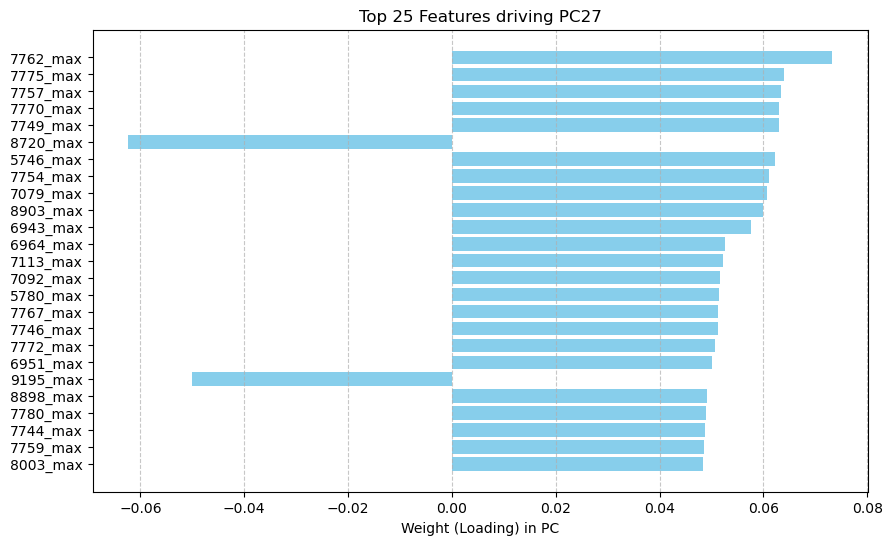

In [157]:

import matplotlib.pyplot as plt

def inspect_pca_component(pca_model, feature_names, pc_index=26, top_n=25):
    # 1. Extract the weights for the specific PC
    weights = pca_model.components_[pc_index]

    # print weights statistics
    abs_weights = np.abs(weights)
    print(f"PC{pc_index + 1} Absolute value Weights Statistics:")
    print(f"  Mean: {np.mean(abs_weights):.4f}")
    print(f"  Std Dev: {np.std(abs_weights):.4f}")
    print(f"  Min: {np.min(abs_weights):.4f}")
    print(f"  Max: {np.max(abs_weights):.4f}")
    print(f"  Median: {np.median(abs_weights):.4f}")
    print(f"  25th Percentile: {np.percentile(abs_weights, 25):.4f}")
    print(f"  75th Percentile: {np.percentile(abs_weights, 75):.4f}")
    print(f"  95th Percentile: {np.percentile(abs_weights, 95):.4f}")
    
    # 2. Get the absolute values to find the "most influential" regardless of direction
    abs_weights = np.abs(weights)
    
    # 3. Sort and get top N indices
    top_indices = np.argsort(abs_weights)[::-1][:top_n]
    
    # 4. Create a summary dataframe
    top_features = []
    for idx in top_indices:
        top_features.append({
            'Feature': feature_names[idx],
            'Weight': weights[idx],
            'AbsWeight': abs_weights[idx]
        })
    
    df_top = pd.DataFrame(top_features)
    
    # 5. Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(df_top['Feature'], df_top['Weight'], color='skyblue')
    plt.xlabel('Weight (Loading) in PC')
    plt.title(f'Top {top_n} Features driving PC{pc_index + 1}')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
    return df_top

# Usage:
df_top_kernels = inspect_pca_component(pca_rocket, video_level_rocket.columns, pc_index=26, top_n=25)#int(top_rocket_pc[-2:])-1)

In [158]:
df_top_kernels

,Feature,Weight,AbsWeight
0,7762_max,0.073264,0.073264
1,7775_max,0.063866,0.063866
2,7757_max,0.063431,0.063431
3,7770_max,0.062993,0.062993
4,7749_max,0.062993,0.062993
5,8720_max,-0.062409,0.062409
6,5746_max,0.062152,0.062152
7,7754_max,0.060986,0.060986
8,7079_max,0.060674,0.060674
9,8903_max,0.059915,0.059915


In [159]:
def get_minirocket_props_v2(rocket_model):
    """
    Attempts to find the dilation and channel indices across different sktime versions.
    """
    # 1. Try to find the transformer object
    # Often it's stored in self.transformer_ or self.minirocket_
    if hasattr(rocket_model, "transformer_"):
        inner = rocket_model.transformer_
    elif hasattr(rocket_model, "_transformer"):
        inner = rocket_model._transformer
    else:
        inner = rocket_model

    # 2. Access dilations and features per dilation
    try:
        # Some versions use .dilations, others ._dilations, others .parameters
        dilations = getattr(inner, "dilations", None)
        num_features = getattr(inner, "num_features_per_dilation", None)
        
        if dilations is None and hasattr(inner, "parameters"):
            # If it's the raw parameter tuple (dilations, num_features_per_dilation, ...)
            dilations = inner.parameters[0]
            num_features = inner.parameters[1]
            
        return dilations, num_features
    except Exception as e:
        print(f"Could not extract: {e}")
        return None, None

# Let's apply it to your Top PC
dilations, num_features_per_dilation = get_minirocket_props_v2(rocket)

if dilations is not None:
    # 3. Backtrack the feature index
    # (top_idx // 3) because each kernel has Mean, Max, Std
    kernel_idx = top_idx // 3
    cumulative_features = np.cumsum(num_features_per_dilation)
    dilation_group = np.searchsorted(cumulative_features, kernel_idx)
    
    expert_dilation = dilations[dilation_group]
    print(f"✅ Success! Expert Kernel Dilation: {expert_dilation} frames")
    print(f"Physical meaning: This kernel 'sees' patterns over {expert_dilation/10:.2f} seconds.")
else:
    # If the above still fails, we can use a "Brute Force" check
    print("❌ Attributes still hidden. Try: dir(rocket) to see available names.")

NameError: name 'top_idx' is not defined

In [ ]:
def analyze_expert_kernels(rocket_model, pca_model, pc_index=27, top_k=3):
    """
    Extracts the underlying MiniRocket parameters for the kernels
    that dominate a specific PCA component.
    """
    # 1. Get loadings and find top kernels
    # Note: If your features are [K1_mean, K1_max, K1_std...], 
    # the kernel index is floor(feature_index / 3)
    weights = pca_model.components_[pc_index]
    top_feature_indices = np.argsort(np.abs(weights))[::-1][:top_k]
    
    print(f"--- Analysis of Top {top_k} Kernels for PC{pc_index+1} ---")
    
    for feat_idx in top_feature_indices:
        kernel_idx = feat_idx // 3 # Adjust based on your actual feature column order
        agg_type = ['mean', 'max', 'std'][feat_idx % 3]
        weight = weights[feat_idx]
        
        # Access parameters from MiniRocket
        # MiniRocket uses 84 fixed patterns; we find which one this kernel uses
        # Note: Depending on your sktime version, parameter access might vary
        dilation = rocket_model.dilations_[kernel_idx]
        num_features_per_dilation = rocket_model.num_features_per_dilation_
        
        print(f"\nFeature: Kernel_{kernel_idx}_{agg_type}")
        print(f"Weight in PC: {weight:.4f}")
        print(f"Dilation (Scale): {dilation} frames (~{dilation/10:.2f} seconds)")
        
        # Visualize the pattern (Conceptual - MiniRocket uses PPV of 84 linear patterns)
        # We can plot a synthetic version of the 'Expert' motion this kernel likes
    
    return top_feature_indices

top_indices = analyze_expert_kernels(rocket, pca_rocket)

--- Analysis of Top 3 Kernels for PC28 ---


AttributeError: 'MiniRocketMultivariate' object has no attribute 'dilations_'